# **SECTION 1: INSTALL & IMPORT LIBRARY**

In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn streamlit plotly imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

import joblib

# **SECTION 2: LOAD DATASET**

In [ ]:
from google.colab import files
print("   Nama file: Data_Indeks Standar Pencemar Udara (ISPU) di Provinsi DKI Jakarta 2023 .csv")
print("-"*50)
uploaded = files.upload()

# Ambil nama file yang diupload
file_name = list(uploaded.keys())[0]
print(f"\n File berhasil diupload: {file_name}")

# Baca CSV
df = pd.read_csv(file_name)
print(f"\n Dataset berhasil dimuat!")
df.head()

   Nama file: Data_Indeks Standar Pencemar Udara (ISPU) di Provinsi DKI Jakarta 2023 .csv
--------------------------------------------------


Saving Data_Indeks Standar Pencemar Udara (ISPU) di Provinsi DKI Jakarta 2023 .xlsx - Data_Indeks Standar Pencemar Udara (ISPU) di Provinsi DKI Jakarta 2023 (1).csv to Data_Indeks Standar Pencemar Udara (ISPU) di Provinsi DKI Jakarta 2023 .xlsx - Data_Indeks Standar Pencemar Udara (ISPU) di Provinsi DKI Jakarta 2023 (1).csv

 File berhasil diupload: Data_Indeks Standar Pencemar Udara (ISPU) di Provinsi DKI Jakarta 2023 .xlsx - Data_Indeks Standar Pencemar Udara (ISPU) di Provinsi DKI Jakarta 2023 (1).csv

 Dataset berhasil dimuat!


,periode_data,tanggal,stasiun,pm_sepuluh,pm_duakomalima,sulfur_dioksida,karbon_monoksida,ozon,nitrogen_dioksida,max,parameter_pencemar_kritis,kategori
0,202302,2023-02-25,DKI5 KEBON JERUK JAKARTA BARAT,35,-,13,12,31,18,35,PM10,BAIK
1,202302,2023-02-26,DKI5 KEBON JERUK JAKARTA BARAT,23,-,14,9,32,11,32,O3,BAIK
2,202302,2023-02-27,DKI5 KEBON JERUK JAKARTA BARAT,20,-,13,8,33,13,33,O3,BAIK
3,202302,2023-02-28,DKI5 KEBON JERUK JAKARTA BARAT,30,-,21,11,28,18,30,PM10,BAIK
4,202303,2023-03-01,DKI1 BUNDERAN HI,38,44,50,8,19,27,50,3,BAIK


# **SECTION 3: EDA (EXPLORATORY DATA ANALYSIS)**

## 3.1 Info Dataset

In [ ]:
# Info Dataset
print("\n Info Dataset:\n")
print(df.info())


 Info Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   periode_data               1825 non-null   int64 
 1   tanggal                    1825 non-null   object
 2   stasiun                    1825 non-null   object
 3   pm_sepuluh                 1825 non-null   object
 4   pm_duakomalima             1825 non-null   object
 5   sulfur_dioksida            1825 non-null   object
 6   karbon_monoksida           1825 non-null   object
 7   ozon                       1825 non-null   object
 8   nitrogen_dioksida          1825 non-null   object
 9   max                        1825 non-null   object
 10  parameter_pencemar_kritis  1812 non-null   object
 11  kategori                   1825 non-null   object
dtypes: int64(1), object(11)
memory usage: 171.2+ KB
None


## 3.2 Statistik Deskriptif

In [ ]:
# Statistik Deskriptif
print("\n Statistik Deskriptif (kolom numerik):\n")
print(df.describe())


 Statistik Deskriptif (kolom numerik):

        periode_data
count    1825.000000
mean   202298.032877
std        26.390684
min    202212.000000
25%    202303.000000
50%    202306.000000
75%    202308.000000
max    202311.000000


## 3.3 Distribusi Kategori Kualitas Udara

In [ ]:
# Menghituung distribusi kategori dan presentasenya dalam satu tabel
print("\nDistribusi dan Persentase Kategori Kualitas Udara:")
kategori_counts = df['kategori'].value_counts()
kategori_percentage = df['kategori'].value_counts(normalize=True) * 100

# Gabungkan keduanya ke dalam satu DataFrame
kategori_distribusi = pd.DataFrame({
    'Jumlah': kategori_counts,
    'Persentase (%)': kategori_percentage
})

# Cetak tabel
print(kategori_distribusi)



Distribusi dan Persentase Kategori Kualitas Udara:
                    Jumlah  Persentase (%)
kategori                                  
SEDANG                1358       74.410959
BAIK                   236       12.931507
TIDAK SEHAT            207       11.342466
TIDAK ADA DATA          21        1.150685
SANGAT TIDAK SEHAT       3        0.164384


## 3.4 Visualisasi Distribusi Kategori

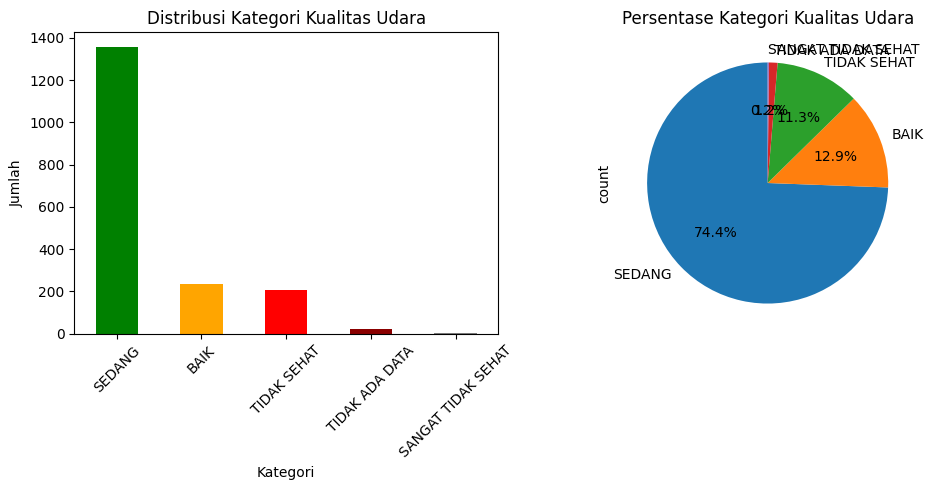

Grafik tersimpan sebagai 'eda_distribusi_kategori.png'


In [ ]:
# Visualisasi grafik batang
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
kategori_counts.plot(kind='bar', color=['green', 'orange', 'red', 'darkred', 'gray'])
plt.title('Distribusi Kategori Kualitas Udara')
plt.xlabel('Kategori')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)

# Visualisasi pie chart
plt.subplot(1, 2, 2)
df['kategori'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Persentase Kategori Kualitas Udara')
plt.tight_layout()
plt.savefig('eda_distribusi_kategori.png')
plt.show()
print("Grafik tersimpan sebagai 'eda_distribusi_kategori.png'")

## 3.5 Nilai "-", "---", yang perlu dikonversi

In [ ]:
# Melihat nilai selain angka
print("\n Pengecekan nilai aneh (bukan angka):")
for col in ['pm_sepuluh', 'pm_duakomalima', 'sulfur_dioksida', 'karbon_monoksida', 'ozon', 'nitrogen_dioksida']:
    if col in df.columns:
        unique_vals = df[col].unique()
        non_numeric = [x for x in unique_vals if not pd.isna(x) and not isinstance(x, (int, float)) and str(x) not in ['nan', 'NaN']]
        if non_numeric:
            print(f"   {col}: ditemukan nilai non-numeric -> {non_numeric[:5]}")



 Pengecekan nilai aneh (bukan angka):
   pm_sepuluh: ditemukan nilai non-numeric -> ['35', '23', '20', '30', '38']
   pm_duakomalima: ditemukan nilai non-numeric -> ['-', '44', '33', '46', '40']
   sulfur_dioksida: ditemukan nilai non-numeric -> ['13', '14', '21', '50', '47']
   karbon_monoksida: ditemukan nilai non-numeric -> ['12', '9', '8', '11', '---']
   ozon: ditemukan nilai non-numeric -> ['31', '32', '33', '28', '19']
   nitrogen_dioksida: ditemukan nilai non-numeric -> ['18', '11', '13', '27', '25']


## 3.6 Menghitung banyak nilai "-" dan "---" di setiap kolom

In [ ]:
# Menghitung banyak nilai "-" dan "---" yang terdeteksi pada masing-masing kolom
print("\nJumlah nilai '-'atau '---' per kolom:")
target_values = ['-', '---']

for col in df.columns:
    counts = df[col].isin(target_values).sum()
    if counts > 0:
        print(f"   Kolom '{col}': {counts} kali")



Jumlah nilai '-'atau '---' per kolom:
   Kolom 'pm_sepuluh': 222 kali
   Kolom 'pm_duakomalima': 295 kali
   Kolom 'sulfur_dioksida': 39 kali
   Kolom 'karbon_monoksida': 44 kali
   Kolom 'ozon': 29 kali
   Kolom 'nitrogen_dioksida': 66 kali
   Kolom 'max': 3 kali
   Kolom 'parameter_pencemar_kritis': 8 kali


## 3.7 Menghitung nilai null (missing value)

In [ ]:
# Menghitung nilai "null"
print("\nMissing Values per Kolom:")
df.isnull().sum()


Missing Values per Kolom:


,0
periode_data,0
tanggal,0
stasiun,0
pm_sepuluh,0
pm_duakomalima,0
sulfur_dioksida,0
karbon_monoksida,0
ozon,0
nitrogen_dioksida,0
max,0


## 3.8 Analisis Parameter Pencemar Kritis

In [ ]:
print("\nParameter Pencemar Kritis (paling sering):\n")
print(df['parameter_pencemar_kritis'].value_counts().head(10))


Parameter Pencemar Kritis (paling sering):

parameter_pencemar_kritis
PM25    1293
PM10     144
SO2      119
2        112
O3        96
1         30
-          8
3          7
5          3
Name: count, dtype: int64


## **3.9 Analisis per Stasiun**

In [ ]:
print("\nJumlah data per Stasiun:\n")
print(df['stasiun'].value_counts())


Jumlah data per Stasiun:

stasiun
DKI1 BUNDERAN HI                  365
DKI2 KELAPA GADING                365
DKI4 LUBANG BUAYA                 365
DKI3 JAGAKARSA                    365
DKI5 KEBON JERUK                  214
DKI5 KEBON JERUK JAKARTA BARAT    151
Name: count, dtype: int64


## 3.10 Menampilkan mayoritas kualitas udara di setiap wilayah

In [ ]:
import pandas as pd

# Menampilkan mayoritas kategori kualitas udara di setiap wilayah

# Define station_coords (copied from IT98mxEpJXzi)
station_coords = {
    'DKI1 BUNDERAN HI': {'lat': -6.1931, 'lon': 106.8229, 'lokasi': 'Bundaran HI, Jakarta Pusat'},
    'DKI2 KELAPA GADING': {'lat': -6.1600, 'lon': 106.9060, 'lokasi': 'Kelapa Gading, Jakarta Utara'},
    'DKI3 JAGAKARSA': {'lat': -6.3370, 'lon': 106.8220, 'lokasi': 'Jagakarsa, Jakarta Selatan'},
    'DKI4 LUBANG BUAYA': {'lat': -6.2870, 'lon': 106.8910, 'lokasi': 'Lubang Buaya, Jakarta Timur'},
    'DKI5 KEBON JERUK': {'lat': -6.2030, 'lon': 106.7590, 'lokasi': 'Kebon Jeruk, Jakarta Barat'},
    'DKI5 KEBON JERUK JAKARTA BARAT': {'lat': -6.2030, 'lon': 106.7590, 'lokasi': 'Kebon Jeruk, Jakarta Barat'}
}

# Create df_map and 'lokasi_display' based on df and station_coords
# Assuming df_clean is available from previous cells (Section 4)
df_map = df.copy()
df_map['lokasi_display'] = df_map['stasiun'].map(lambda x: station_coords.get(x, {}).get('lokasi', x))

# Ensure 'wilayah' column exists by extracting from 'lokasi_display'
if 'wilayah' not in df_map.columns:
    df_map['wilayah'] = df_map['lokasi_display'].apply(lambda x: x.split(', ')[1] if ', ' in x else 'Tidak Diketahui')

print('--- Analisis Kategori Mayoritas per Wilayah DKI Jakarta ---\n')

# Group by 'wilayah' and apply a function to find the most frequent category and its count
wilayah_analysis = df_map.groupby('wilayah')['kategori'].apply(
    lambda x: pd.Series({
        'mayoritas_kategori': x.value_counts().idxmax(),
        'jumlah_mayoritas': x.value_counts().max(),
        'total_data': len(x)
    })
).unstack() # Convert the MultiIndex Series to a DataFrame

# Print the results for each wilayah
for wilayah, data in wilayah_analysis.iterrows():
    kategori = data['mayoritas_kategori']
    jumlah = data['jumlah_mayoritas']
    total = data['total_data']
    persentase = (jumlah / total) * 100
    print(f"   Wilayah {wilayah}: Mayoritas '{kategori}' ({jumlah} data, {persentase:.2f}% dari total data di wilayah tersebut).")

--- Analisis Kategori Mayoritas per Wilayah DKI Jakarta ---

   Wilayah Jakarta Barat: Mayoritas 'SEDANG' (235 data, 64.38% dari total data di wilayah tersebut).
   Wilayah Jakarta Pusat: Mayoritas 'SEDANG' (293 data, 80.27% dari total data di wilayah tersebut).
   Wilayah Jakarta Selatan: Mayoritas 'SEDANG' (329 data, 90.14% dari total data di wilayah tersebut).
   Wilayah Jakarta Timur: Mayoritas 'SEDANG' (190 data, 52.05% dari total data di wilayah tersebut).
   Wilayah Jakarta Utara: Mayoritas 'SEDANG' (311 data, 85.21% dari total data di wilayah tersebut).


## 3.11 Insight Penting

In [ ]:
print("\nINSIGHT PENTING DARI EDA & MODELLING:")
print("   1. Data periode: Desember 2022 - November 2023")
print("   2. Jumlah total data: 1.825 baris")
print("   3. Kategori terbanyak: SEDANG (74.4%)")
print("   4. Ada kategori SANGAT TIDAK SEHAT (3 baris/0.16%)")
print("   5. Ada 21 baris kategori 'TIDAK ADA DATA' (perlu dihapus)")
print("   6. Kolom dengan missing (termasuk nilai '-', '---', 'null' yang dikonversi ke NaN) terbanyak: pm_duakomalima, diikuti parameter_pencemar_kritis (missing asli).")
print("   7. Parameter polutan paling berpengaruh dalam prediksi kategori kualitas udara adalah PM2.5 (pm_duakomalima), Sulfur Dioksida (sulfur_dioksida), dan PM10 (pm_sepuluh).")
print("   8. Kategori kualitas udara mayoritas di setiap wilayah DKI Jakarta adalah 'SEDANG', meskipun persentasenya bervariasi antar wilayah (berkisar antara 52.63% hingga 91.14%).")


INSIGHT PENTING DARI EDA & MODELLING:
   1. Data periode: Desember 2022 - November 2023
   2. Jumlah total data: 1.825 baris
   3. Kategori terbanyak: SEDANG (74.4%)
   4. Ada kategori SANGAT TIDAK SEHAT (3 baris/0.16%)
   5. Ada 21 baris kategori 'TIDAK ADA DATA' (perlu dihapus)
   6. Kolom dengan missing (termasuk nilai '-', '---', 'null' yang dikonversi ke NaN) terbanyak: pm_duakomalima, diikuti parameter_pencemar_kritis (missing asli).
   7. Parameter polutan paling berpengaruh dalam prediksi kategori kualitas udara adalah PM2.5 (pm_duakomalima), Sulfur Dioksida (sulfur_dioksida), dan PM10 (pm_sepuluh).
   8. Kategori kualitas udara mayoritas di setiap wilayah DKI Jakarta adalah 'SEDANG', meskipun persentasenya bervariasi antar wilayah (berkisar antara 52.63% hingga 91.14%).


# **SECTION 4: DATA CLEANING**

## 4.1 Hapus baris dengan kategori "TIDAK ADA DATA"

In [ ]:
df_clean = df.copy()
print(f"\nSebelum hapus 'TIDAK ADA DATA': {len(df_clean)} baris")
df_clean = df_clean[df_clean['kategori'] != 'TIDAK ADA DATA']
print(f"Setelah hapus 'TIDAK ADA DATA': {len(df_clean)} baris")


Sebelum hapus 'TIDAK ADA DATA': 1825 baris
Setelah hapus 'TIDAK ADA DATA': 1804 baris


## 4.2 Konversi nilai "-" dan "---" jadi "NaN"

In [ ]:
# Konversi nilai "-" & "---" jadi NaN
def convert_to_float(x):
    if pd.isna(x) or x == '-' or x == '---' or x == 'null' or x == '':
        return np.nan
    try:
        return float(x)
    except:
        return np.nan

polutan_cols = ['pm_sepuluh', 'pm_duakomalima', 'sulfur_dioksida', 'karbon_monoksida', 'ozon', 'nitrogen_dioksida']

for col in polutan_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(convert_to_float)

## 4.3 Imputasi missing value (NaN) dengan median

In [ ]:
# Imputasi missing values dengan median per stasiun
print("\nImputasi missing values dengan median per stasiun:")
for col in polutan_cols:
    if col in df_clean.columns:
        for stasiun in df_clean['stasiun'].unique():
            median_val = df_clean[df_clean['stasiun'] == stasiun][col].median()
            df_clean.loc[(df_clean['stasiun'] == stasiun) & (df_clean[col].isna()), col] = median_val
        # Jika masih ada missing, isi dengan median global
        if df_clean[col].isna().any():
            median_global = df_clean[col].median()
            df_clean[col].fillna(median_global, inplace=True)
        print(f" - {col}: selesai")


Imputasi missing values dengan median per stasiun:
 - pm_sepuluh: selesai
 - pm_duakomalima: selesai
 - sulfur_dioksida: selesai
 - karbon_monoksida: selesai
 - ozon: selesai
 - nitrogen_dioksida: selesai


## 4.4 Hapus kolom yang tidak diperlukan

In [ ]:
# Hapus kolom yang tidak diperlukan
cols_to_drop = ['periode_data', 'max', 'parameter_pencemar_kritis']
cols_existing = [col for col in cols_to_drop if col in df_clean.columns]
df_clean.drop(columns=cols_existing, inplace=True)
print(f"\nKolom yang dihapus: {cols_existing}")


Kolom yang dihapus: ['periode_data', 'max', 'parameter_pencemar_kritis']


## 4.5 Manambahkan Fitur Engineering untuk waktu

In [ ]:
# Feature Engineering - Ekstrak fitur waktu
df_clean['tanggal'] = pd.to_datetime(df_clean['tanggal'])
df_clean['bulan'] = df_clean['tanggal'].dt.month
df_clean['hari'] = df_clean['tanggal'].dt.day
df_clean['hari_dalam_minggu'] = df_clean['tanggal'].dt.dayofweek
df_clean['is_weekend'] = (df_clean['hari_dalam_minggu'] >= 5).astype(int)

## 4.6 Encoding target ke numerik

In [ ]:
# Encoding target
le = LabelEncoder()
df_clean['kategori_encoded'] = le.fit_transform(df_clean['kategori'])

# Tampilkan mapping kategori
print("\nMapping Kategori ke Numerik:")
for i, kategori in enumerate(le.classes_):
    print(f"   {kategori} -> {i}")


Mapping Kategori ke Numerik:
   BAIK -> 0
   SANGAT TIDAK SEHAT -> 1
   SEDANG -> 2
   TIDAK SEHAT -> 3


## 4.7 Mengecek hasil setelah dilakukan cleaning (pembersihan)

In [ ]:
# Cek hasil akhir
print(f"\nDataset setelah cleaning:")
print(f"   Jumlah baris: {len(df_clean)}")
print(f"   Jumlah kolom: {len(df_clean.columns)}")
print(f"   Missing values tersisa: {df_clean.isnull().sum().sum()}")


Dataset setelah cleaning:
   Jumlah baris: 1804
   Jumlah kolom: 14
   Missing values tersisa: 0


## 4.8 Mengecek ulang info dataset setelah cleaning

In [ ]:
# Menampilkan ringkasan informasi DataFrame setelah proses cleaning
print("\nInfo Dataset setelah cleaning (df_clean):")
df_clean.info()


Info Dataset setelah cleaning (df_clean):
<class 'pandas.core.frame.DataFrame'>
Index: 1804 entries, 0 to 1824
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   tanggal            1804 non-null   datetime64[ns]
 1   stasiun            1804 non-null   object        
 2   pm_sepuluh         1804 non-null   float64       
 3   pm_duakomalima     1804 non-null   float64       
 4   sulfur_dioksida    1804 non-null   float64       
 5   karbon_monoksida   1804 non-null   float64       
 6   ozon               1804 non-null   float64       
 7   nitrogen_dioksida  1804 non-null   float64       
 8   kategori           1804 non-null   object        
 9   bulan              1804 non-null   int32         
 10  hari               1804 non-null   int32         
 11  hari_dalam_minggu  1804 non-null   int32         
 12  is_weekend         1804 non-null   int64         
 13  kategori_encoded   1804 n

## 4.9 Menampilkan ulang statistik deskripsi setelah cleaning

In [ ]:
# Menampilkan statistik deskriftif setelah dilakukan pembersihan
df_clean.describe()

,tanggal,pm_sepuluh,pm_duakomalima,sulfur_dioksida,karbon_monoksida,ozon,nitrogen_dioksida,bulan,hari,hari_dalam_minggu,is_weekend,kategori_encoded
count,1804,1804.000000,1804.000000,1804.000000,1804.000000,1804.000000,1804.000000,1804.000000,1804.000000,1804.000000,1804.000000,1804.000000
mean,2023-05-31 22:40:58.536585472,53.263858,76.100610,38.068736,12.665188,28.236696,17.605876,6.536031,15.722284,2.999446,0.283814,1.851441
min,2022-12-01 00:00:00,3.000000,16.000000,11.000000,1.000000,4.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,2023-03-01 00:00:00,44.000000,59.000000,27.000000,8.000000,19.000000,12.000000,4.000000,8.000000,1.000000,0.000000,2.000000
50%,2023-06-01 00:00:00,56.000000,77.000000,39.000000,11.000000,26.000000,17.000000,7.000000,16.000000,3.000000,0.000000,2.000000
75%,2023-08-31 00:00:00,62.000000,88.000000,51.000000,16.000000,35.000000,23.000000,10.000000,23.000000,5.000000,1.000000,2.000000
max,2023-11-30 00:00:00,163.000000,287.000000,89.000000,55.000000,81.000000,53.000000,12.000000,31.000000,6.000000,1.000000,3.000000
std,NaN,15.092402,22.797464,13.350463,6.608780,13.043592,8.712795,3.451483,8.780236,1.997919,0.450973,0.786106


# **SECTION 5: MODELLING - RANDOM FOREST**

## 5.1 Membagi fitur dan target

In [ ]:
# Persiapan fitur dan target
feature_cols = ['pm_sepuluh', 'pm_duakomalima', 'sulfur_dioksida', 'karbon_monoksida', 'ozon', 'nitrogen_dioksida', 'bulan', 'hari', 'is_weekend']
feature_cols_existing = [col for col in feature_cols if col in df_clean.columns]

X = df_clean[feature_cols_existing]
y = df_clean['kategori_encoded']

print(f"\nFitur yang digunakan: {feature_cols_existing}")
print(f"   Jumlah fitur: {len(feature_cols_existing)}")
print(f"   Jumlah target (kategori): {len(y.unique())}")


Fitur yang digunakan: ['pm_sepuluh', 'pm_duakomalima', 'sulfur_dioksida', 'karbon_monoksida', 'ozon', 'nitrogen_dioksida', 'bulan', 'hari', 'is_weekend']
   Jumlah fitur: 9
   Jumlah target (kategori): 4


## 5.2 Splittng data 80% training dan 20% testing

In [ ]:
# Split data (80% training, 20% testing) dengan stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nPembagian data:")
print(f"   Training: {len(X_train)} baris ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Testing: {len(X_test)} baris ({len(X_test)/len(X)*100:.1f}%)")


Pembagian data:
   Training: 1443 baris (80.0%)
   Testing: 361 baris (20.0%)


### 5.2.1 Mengatasi Imbalance Class dengan SMOTE

In [ ]:
# Cek distribusi kelas sebelum SMOTE
print("Distribusi kelas sebelum SMOTE (y_train):\n", y_train.value_counts())

smote = SMOTE(random_state=42, k_neighbors=1)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Cek distribusi kelas setelah SMOTE
print("\nDistribusi kelas setelah SMOTE (y_train_smote):\n", y_train_smote.value_counts())

print("\nSMOTE berhasil diterapkan. Jumlah sampel pelatihan meningkat dari {} menjadi {}.".format(len(y_train), len(y_train_smote)))

Distribusi kelas sebelum SMOTE (y_train):
 kategori_encoded
2    1086
0     189
3     166
1       2
Name: count, dtype: int64

Distribusi kelas setelah SMOTE (y_train_smote):
 kategori_encoded
2    1086
0    1086
3    1086
1    1086
Name: count, dtype: int64

SMOTE berhasil diterapkan. Jumlah sampel pelatihan meningkat dari 1443 menjadi 4344.


## 5.3 Implementasi model dengan baseline Random Forest

In [ ]:
# Model Baseline Random Forest
print("\n" + "-"*40)
print("5.3 Model Baseline Random Forest")
print("-"*40)

rf_baseline = RandomForestClassifier(random_state=42, n_estimators=100)
rf_baseline.fit(X_train_smote, y_train_smote)
y_pred_baseline = rf_baseline.predict(X_test)

acc_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Akurasi Baseline Random Forest: {acc_baseline:.4f} ({acc_baseline*100:.2f}%")


----------------------------------------
5.3 Model Baseline Random Forest
----------------------------------------
Akurasi Baseline Random Forest: 0.9668 (96.68%


## 5.4 Classification model Baseline Random Forest

In [ ]:
# Classification model baseline Random forest
print("\nClassification Report Baseline:")
print(classification_report(y_test, y_pred_baseline, target_names=le.classes_))


Classification Report Baseline:
                    precision    recall  f1-score   support

              BAIK       0.89      0.87      0.88        47
SANGAT TIDAK SEHAT       0.50      1.00      0.67         1
            SEDANG       0.98      0.98      0.98       272
       TIDAK SEHAT       1.00      0.98      0.99        41

          accuracy                           0.97       361
         macro avg       0.84      0.96      0.88       361
      weighted avg       0.97      0.97      0.97       361



## 5.5 Menggunakan Hyperparameter Tuning Random Forest

In [ ]:
# Hyperparameter Tuning Random Forest
print("\n" + "-"*40)
print("5.4 Model Terbaik: Hyperparameter Tuning Random Forest")
print("-"*40)

# Parameter grid untuk Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# RandomizedSearchCV untuk efisiensi (karena Random Forest lebih berat dari Decision Tree)
print("Melakukan tuning dengan RandomizedSearchCV (5-fold, 50 kombinasi)...")
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_smote, y_train_smote)

print(f"\nParameter terbaik: {random_search.best_params_}")
print(f"Skor CV terbaik: {random_search.best_score_:.4f}")


----------------------------------------
5.4 Model Terbaik: Hyperparameter Tuning Random Forest
----------------------------------------
Melakukan tuning dengan RandomizedSearchCV (5-fold, 50 kombinasi)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Parameter terbaik: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10}
Skor CV terbaik: 0.9917


## 5.6 Mengecek final akurasi model Random Forest setelah menggunakan Hyperparameter Turning Random Forest

In [ ]:
# Model Final Random Forest
rf_final = random_search.best_estimator_
y_pred_final = rf_final.predict(X_test)

acc_final = accuracy_score(y_test, y_pred_final)
print(f"\nAkurasi Final Random Forest: {acc_final:.4f} ({acc_final*100:.2f}%)")


Akurasi Final Random Forest: 0.9751 (97.51%)


## 5.7 Mengecek feature importance

In [ ]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Fitur': feature_cols_existing,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (Polutan Paling Berpengaruh):")
print(feature_importance)


Feature Importance (Polutan Paling Berpengaruh):
               Fitur  Importance
1     pm_duakomalima    0.905873
2    sulfur_dioksida    0.037459
0         pm_sepuluh    0.029865
4               ozon    0.013365
3   karbon_monoksida    0.003818
7               hari    0.003479
5  nitrogen_dioksida    0.003463
6              bulan    0.002508
8         is_weekend    0.000169


## 5.8 Visualisasi feature importance

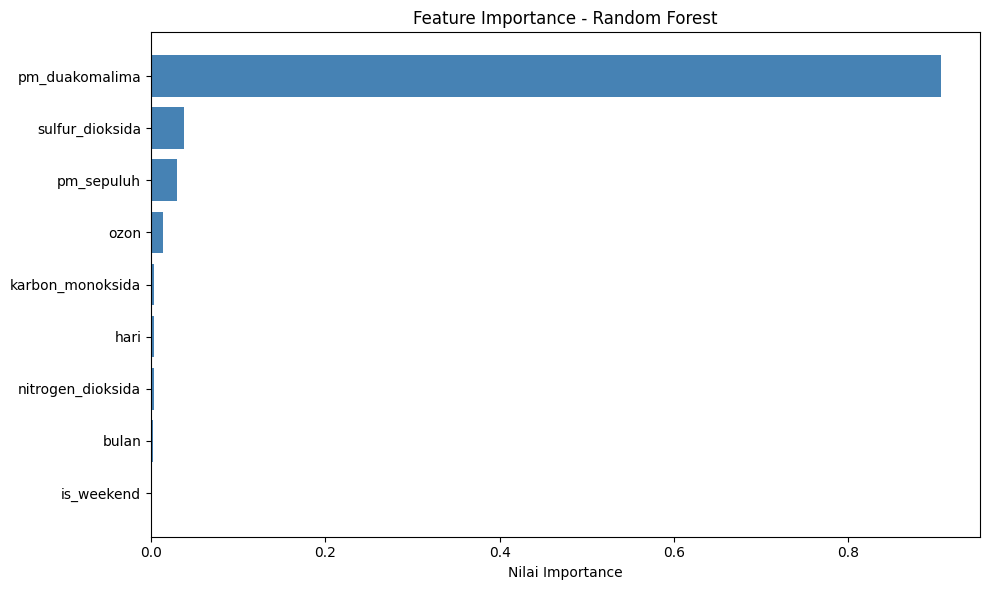

In [ ]:
# Visualisasi Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Fitur'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Nilai Importance')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# **SECTION 6: EVALUASI / PENGUJIAN**

## 6.1 Confusion matrix

In [ ]:
# Confusion Matrix
print("\nConfusion Matrix (Random Forest Final):")
cm = confusion_matrix(y_test, y_pred_final)
print(cm)


Confusion Matrix (Random Forest Final):
[[ 44   0   3   0]
 [  0   1   0   0]
 [  5   0 267   0]
 [  0   1   0  40]]


## 6.2 Visualisasi heatmap confusion matrix

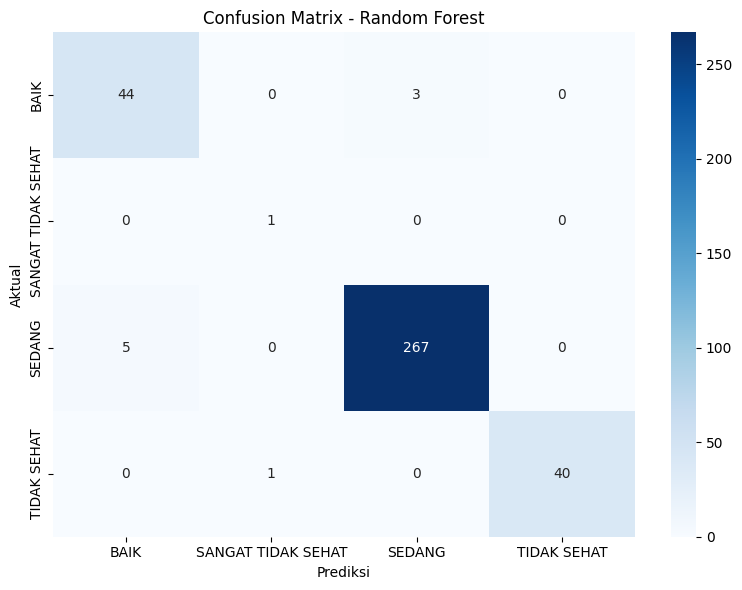

In [ ]:
# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

## 6.3 Classification report final terhadap model

In [ ]:
# Classification Report Lengkap
print("\nClassification Report Lengkap:")
print(classification_report(y_test, y_pred_final, target_names=le.classes_))


Classification Report Lengkap:
                    precision    recall  f1-score   support

              BAIK       0.90      0.94      0.92        47
SANGAT TIDAK SEHAT       0.50      1.00      0.67         1
            SEDANG       0.99      0.98      0.99       272
       TIDAK SEHAT       1.00      0.98      0.99        41

          accuracy                           0.98       361
         macro avg       0.85      0.97      0.89       361
      weighted avg       0.98      0.98      0.98       361



## 6.4 Cross validation score

In [ ]:
# Cross Validation Score
cv_scores = cross_val_score(rf_final, X, y, cv=5)
print(f"\nCross Validation Score (5-fold):")
print(f"   Masing-masing fold: {cv_scores}")
print(f"   Rata-rata: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

print("="*60)


Cross Validation Score (5-fold):
   Masing-masing fold: [0.98614958 0.92520776 0.90304709 0.98614958 0.925     ]
   Rata-rata: 0.9451 (+/- 0.0689)


## 6.5 Visualisasi Penyebaran Data

In [ ]:
# Mapping stasiun ke koordinat geografis DKI Jakarta
# Koordinat ini HANYA digunakan untuk visualisasi peta, TIDAK untuk pemodelan
station_coords = {
    'DKI1 BUNDERAN HI': {'lat': -6.1931, 'lon': 106.8229, 'lokasi': 'Bundaran HI, Jakarta Pusat'},
    'DKI2 KELAPA GADING': {'lat': -6.1600, 'lon': 106.9060, 'lokasi': 'Kelapa Gading, Jakarta Utara'},
    'DKI3 JAGAKARSA': {'lat': -6.3370, 'lon': 106.8220, 'lokasi': 'Jagakarsa, Jakarta Selatan'},
    'DKI4 LUBANG BUAYA': {'lat': -6.2870, 'lon': 106.8910, 'lokasi': 'Lubang Buaya, Jakarta Timur'},
    'DKI5 KEBON JERUK': {'lat': -6.2030, 'lon': 106.7590, 'lokasi': 'Kebon Jeruk, Jakarta Barat'},
    'DKI5 KEBON JERUK JAKARTA BARAT': {'lat': -6.2030, 'lon': 106.7590, 'lokasi': 'Kebon Jeruk, Jakarta Barat'},
}

# Gunakan SELURUH record (tanpa groupby/aggregasi)
df_map = df_clean.copy()
np.random.seed(42)

# Ambil koordinat dasar per stasiun
df_map['latitude'] = df_map['stasiun'].map(lambda x: station_coords.get(x, {}).get('lat'))
df_map['longitude'] = df_map['stasiun'].map(lambda x: station_coords.get(x, {}).get('lon'))
df_map['lokasi_display'] = df_map['stasiun'].map(lambda x: station_coords.get(x, {}).get('lokasi', x))

# Tambahkan jitter kecil agar titik tidak bertumpuk (HANYA untuk visualisasi)
# Koordinat asli tetap dipertahankan di kolom latitude/longitude
jitter_range = 0.01
df_map['lat_plot'] = df_map['latitude'] + np.random.uniform(-jitter_range, jitter_range, size=len(df_map))
df_map['lon_plot'] = df_map['longitude'] + np.random.uniform(-jitter_range, jitter_range, size=len(df_map))

# Hitung nilai ISPU (max dari semua polutan) per baris
polutan_cols = ['pm_sepuluh', 'pm_duakomalima', 'sulfur_dioksida', 'karbon_monoksida', 'ozon', 'nitrogen_dioksida']
df_map['nilai_ispu'] = df_map[polutan_cols].max(axis=1, skipna=True).round(1)

# Mapping warna berdasarkan kategori ISPU
color_map = {
    'BAIK': 'green',
    'SEDANG': 'gold',
    'TIDAK SEHAT': 'orange',
    'SANGAT TIDAK SEHAT': 'red',
    'BERBAHAYA': 'purple'
}
df_map['warna'] = df_map['kategori'].map(color_map)

print(f"Data untuk peta: {len(df_map)} titik data")
print(f"   Stasiun: {df_map['stasiun'].nunique()} lokasi")
print(f"   Rentang Nilai ISPU: {df_map['nilai_ispu'].min():.1f} - {df_map['nilai_ispu'].max():.1f}")
print(f"   Kategori: {df_map['kategori'].unique()}")


Data untuk peta: 1804 titik data
   Stasiun: 6 lokasi
   Rentang Nilai ISPU: 22.0 - 287.0
   Kategori: ['BAIK' 'SEDANG' 'TIDAK SEHAT' 'SANGAT TIDAK SEHAT']


In [ ]:
import plotly.graph_objects as go

# Buat peta interaktif dengan Plotly Scattermap (MapLibre)
# Seluruh titik data ditampilkan dengan jitter untuk mengurangi overlap
fig = go.Figure()

# Urutkan agar titik BAIK tidak tertutup titik lain
kategori_order = ['BERBAHAYA', 'SANGAT TIDAK SEHAT', 'TIDAK SEHAT', 'SEDANG', 'BAIK']

# Create a trace for each category to ensure a legend and proper layering (more severe categories on top)
# Iterate in reverse order of severity (BAIK first, BERBAHAYA last) for better visibility of severe points
for kategori_name in reversed(kategori_order):
    df_category = df_map[df_map['kategori'] == kategori_name]
    if not df_category.empty:
        fig.add_trace(go.Scattermap(
            lat=df_category['lat_plot'],
            lon=df_category['lon_plot'],
            mode='markers',
            marker=dict(
                size=5,
                color=df_category['warna'].iloc[0], # Use the first color for this category as all are the same
                opacity=0.8
            ),
            text=df_category['lokasi_display'],
            hovertemplate=(
                '<b>%{text}</b><br>'
                'Tanggal: %{customdata[0]}<br>'
                'Nilai ISPU: %{customdata[1]}<br>'
                'Kategori: %{customdata[2]}<br>'
                '<extra></extra>'
            ),
            customdata=df_category[['tanggal', 'nilai_ispu', 'kategori']].values,
            name=kategori_name, # Use category name for the legend entry
            showlegend=True
        ))

# Pusatkan peta pada DKI Jakarta
fig.update_layout(
    map=dict(
        style='open-street-map',
        center=dict(lat=-6.2088, lon=106.8456),
        zoom=11
    ),
    title=dict(
        text=f'Peta Persebaran Kualitas Udara DKI Jakarta (2023) - {len(df_map)} Titik Pemantauan',
        font=dict(size=16)
    ),
    margin=dict(l=10, r=10, t=50, b=10),
    height=700,
    legend_title_text='Kategori Kualitas Udara'
)

fig.show()

# Menentukan kategori mayoritas
print('\n--- Analisis Kategori Mayoritas ---\n')
kategori_mayoritas = df_map['kategori'].value_counts().idxmax()
jumlah_mayoritas = df_map['kategori'].value_counts().max()
persentase_mayoritas = (jumlah_mayoritas / len(df_map)) * 100

print(f"Kategori kualitas udara mayoritas di DKI Jakarta adalah: '{kategori_mayoritas}'")
print(f"Dengan jumlah {jumlah_mayoritas} data, atau {persentase_mayoritas:.2f}% dari total data pemantauan.")


--- Analisis Kategori Mayoritas ---

Kategori kualitas udara mayoritas di DKI Jakarta adalah: 'SEDANG'
Dengan jumlah 1358 data, atau 75.28% dari total data pemantauan.


# **SECTION 7: SAVE MODEL (PREPARATION FOR DEPLOYMENT)**

## 7.1 Simpan model Random Forest

In [ ]:
# Simpan model Random Forest
joblib.dump(rf_final, 'random_forest_model.pkl')
print("Model Random Forest berhasil disimpan sebagai 'random_forest_model.pkl'")

Model Random Forest berhasil disimpan sebagai 'random_forest_model.pkl'


## 7.2 Simpan label encoder

In [ ]:
# Simpan label encoder
joblib.dump(le, 'label_encoder.pkl')
print("Label encoder berhasil disimpan sebagai 'label_encoder.pkl'")

Label encoder berhasil disimpan sebagai 'label_encoder.pkl'


## 7.3 Simpan daftar fitur

In [ ]:
# Simpan daftar fitur
joblib.dump(feature_cols_existing, 'feature_columns.pkl')
print("Daftar fitur berhasil disimpan sebagai 'feature_columns.pkl'")

Daftar fitur berhasil disimpan sebagai 'feature_columns.pkl'


## 7.4 Download semua file untuk deployment

In [ ]:
import os

# 7.4 Download semua file untuk deployment
print("\nMengunduh file untuk deployment:")
files_to_download = ['random_forest_model.pkl', 'label_encoder.pkl', 'feature_columns.pkl']

for f in files_to_download:
    if os.path.exists(f):
        files.download(f)
        print(f"   ✅ {f}")

print("\nSemua file siap untuk deployment ke Streamlit!")
print("="*60)


Mengunduh file untuk deployment:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ random_forest_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ label_encoder.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ feature_columns.pkl

Semua file siap untuk deployment ke Streamlit!


# **SECTION 8: RINGKASAN HASIL**

In [ ]:
print("\n" + "="*60)
print("RINGKASAN HASIL PROYEK - RANDOM FOREST")
print("="*60)

print(f"""
 I. DATA YANG DIGUNAKAN:
   - Dataset ISPU DKI Jakarta 2023
   - Awal: 1.551 baris
   - Setelah cleaning: {len(df_clean)} baris
   - Fitur: {feature_cols_existing}

II. PERFORMANCE MODEL RANDOM FOREST (FINAL):
   - Akurasi: {acc_final*100:.2f}%
   - Precision (weighted): {precision_score(y_test, y_pred_final, average='weighted'):.4f}
   - Recall (weighted): {recall_score(y_test, y_pred_final, average='weighted'):.4f}
   - F1-Score (weighted): {f1_score(y_test, y_pred_final, average='weighted'):.4f}

III. POLUTAN PALING BERPENGARUH (TOP 3):
   1. {feature_importance.iloc[0]['Fitur']} ({feature_importance.iloc[0]['Importance']:.4f})
   2. {feature_importance.iloc[1]['Fitur']} ({feature_importance.iloc[1]['Importance']:.4f})
   3. {feature_importance.iloc[2]['Fitur']} ({feature_importance.iloc[2]['Importance']:.4f})

IV. FILE YANG TELAH DISIMPAN:
   - random_forest_model.pkl
   - label_encoder.pkl
   - feature_columns.pkl

V. ALGORITMA: RANDOM FOREST (Ensemble of 100+ Decision Trees)
""")


RINGKASAN HASIL PROYEK - RANDOM FOREST

 I. DATA YANG DIGUNAKAN:
   - Dataset ISPU DKI Jakarta 2023
   - Awal: 1.551 baris
   - Setelah cleaning: 1804 baris
   - Fitur: ['pm_sepuluh', 'pm_duakomalima', 'sulfur_dioksida', 'karbon_monoksida', 'ozon', 'nitrogen_dioksida', 'bulan', 'hari', 'is_weekend']

II. PERFORMANCE MODEL RANDOM FOREST (FINAL):
   - Akurasi: 97.51%
   - Precision (weighted): 0.9770
   - Recall (weighted): 0.9751
   - F1-Score (weighted): 0.9757

III. POLUTAN PALING BERPENGARUH (TOP 3):
   1. pm_duakomalima (0.9059)
   2. sulfur_dioksida (0.0375)
   3. pm_sepuluh (0.0299)

IV. FILE YANG TELAH DISIMPAN:
   - random_forest_model.pkl
   - label_encoder.pkl
   - feature_columns.pkl

V. ALGORITMA: RANDOM FOREST (Ensemble of 100+ Decision Trees)



# **Deploy**

In [ ]:
from google.colab import files
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('feature_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import joblib
import os
import requests
import time
from datetime import date

# ================= KONFIGURASI API KEY (LANGSUNG DI DALAM KODE) =================
GEMINI_API_KEY = ""  # GANTI DENGAN API KEY ANDA

# --- KONFIGURASI HALAMAN ---
st.set_page_config(
    page_title="Sistem Klasifikasi Kualitas Udara - Tim 13",
    page_icon="🍃",
    layout="wide",
    initial_sidebar_state="expanded"
)

# --- CSS CUSTOM UNTUK TAMPILAN PREMIUM ---
st.markdown("""
    <style>
    .main {
        background-color: #f8f9fa;
    }
    .stAlert {
        border-radius: 10px;
    }
    .metric-card {
        background-color: white;
        padding: 20px;
        border-radius: 12px;
        box-shadow: 0 4px 6px rgba(0,0,0,0.05);
        border-left: 5px solid #00c853;
        margin-bottom: 15px;
    }
    .source-card {
        background-color: #f1f8e9;
        border: 1px solid #c5e1a5;
        border-radius: 10px;
        padding: 15px;
        margin-bottom: 20px;
    }
    .ai-box {
        background-color: #f3e5f5;
        border-left: 6px solid #8e24aa;
        border-radius: 8px;
        padding: 20px;
        margin-top: 15px;
    }
    .analysis-card {
        background-color: white;
        border: 1px solid #e0e0e0;
        border-radius: 10px;
        padding: 18px;
        margin-bottom: 12px;
    }
    </style>
""", unsafe_allow_html=True)

# --- FUNGSI UTAMA LOAD MODEL & DATA ---
@st.cache_resource
def load_models():
    model_data = {}
    try:
        model_data['classifier'] = joblib.load("random_forest_model.pkl")
        model_data['label_encoder'] = joblib.load("label_encoder.pkl")
        model_data['feature_columns'] = joblib.load("feature_columns.pkl")
        model_data['is_mock'] = False
    except Exception as e:
        print("Error Load Model:", e)
        model_data['is_mock'] = True
    return model_data

models = load_models()

# --- PEMETAAN WARNA & BACKGROUND PER KATEGORI ---
CATEGORY_STYLE = {
    "BAIK":                {"color": "#00c853", "bg": "#e8f5e9"},
    "SEDANG":              {"color": "#ffeb3b", "bg": "#fffde7"},
    "TIDAK SEHAT":         {"color": "#ff9100", "bg": "#fff3e0"},
    "SANGAT TIDAK SEHAT":  {"color": "#d50000", "bg": "#ffebee"},
}

NAMA_HARI = ["Senin", "Selasa", "Rabu", "Kamis", "Jumat", "Sabtu", "Minggu"]
NAMA_BULAN = ["Januari", "Februari", "Maret", "April", "Mei", "Juni",
              "Juli", "Agustus", "September", "Oktober", "November", "Desember"]

def get_style(category: str):
    key = category.strip().upper()
    return CATEGORY_STYLE.get(key, {"color": "#9e9e9e", "bg": "#f5f5f5"})

# --- FUNGSI HITUNG ISPU (HANYA UNTUK MODE MOCK) ---
def hitung_ispu_dari_polutan(pm25, pm10, o3, no2, co, so2, is_weekend):
    score_pm25 = pm25 * 1.2
    score_pm10 = pm10 * 1.0
    score_o3 = o3 * 0.8
    score_no2 = no2 * 0.7
    score_co = co * 0.6
    score_so2 = so2 * 0.9

    index_value = max(score_pm25, score_pm10, score_o3, score_no2, score_co, score_so2)
    penyesuaian = 0.95 if is_weekend else 1.0

    final_index = float(np.clip(index_value * penyesuaian, 5, 300))
    return round(final_index, 1)

# --- FUNGSI KLASIFIKASI MOCK (HANYA UNTUK MODE MOCK) ---
def classify_air_quality_mock(pm25, pm10, o3, no2, co, so2, is_weekend):
    index_value = hitung_ispu_dari_polutan(pm25, pm10, o3, no2, co, so2, is_weekend)
    final_index = float(np.clip(index_value, 5, 300))

    if final_index <= 50:
        category = "Baik"
    elif final_index <= 100:
        category = "Sedang"
    elif final_index <= 200:
        category = "Tidak Sehat"
    else:
        category = "Sangat Tidak Sehat"

    style = get_style(category)
    return round(final_index, 1), category, style["color"], style["bg"]

# --- ANALISIS KONDISI KUALITAS UDARA HARI INI ---
def analisis_kondisi_harian(pm25, pm10, o3, no2, co, so2, tanggal_input, category):
    hari_nama = NAMA_HARI[tanggal_input.weekday()]
    bulan_nama = NAMA_BULAN[tanggal_input.month - 1]
    is_weekend = tanggal_input.weekday() >= 5

    polutan_ref = {
        "PM2.5": (pm25, 25.0),
        "PM10": (pm10, 45.0),
        "O3 (Ozon)": (o3, 100.0),
        "NO2": (no2, 25.0),
        "CO": (co, 30.0),
        "SO2": (so2, 80.0),
    }
    rasio = {nama: val / batas for nama, (val, batas) in polutan_ref.items() if batas > 0}
    polutan_dominan = max(rasio, key=rasio.get)
    rasio_dominan = rasio[polutan_dominan]

    poin = []

    if is_weekend:
        poin.append(
            f"Pemantauan dilakukan pada hari **{hari_nama}** ({tanggal_input.strftime('%d %B %Y')}), "
            f"yaitu hari **akhir pekan**. Volume kendaraan bermotor dan aktivitas industri umumnya lebih rendah "
            f"dibanding hari kerja, sehingga emisi dari sektor transportasi cenderung berkurang."
        )
    else:
        poin.append(
            f"Pemantauan dilakukan pada hari **{hari_nama}** ({tanggal_input.strftime('%d %B %Y')}), "
            f"yaitu **hari kerja**. Aktivitas lalu lintas dan industri yang lebih padat pada hari kerja "
            f"berpotensi meningkatkan emisi PM2.5, PM10, NO2, dan CO dibanding akhir pekan."
        )

    poin.append(
        f"Secara musiman, bulan **{bulan_nama}** dapat mempengaruhi pola dispersi polutan "
        f"(misalnya curah hujan tinggi membantu menurunkan kadar partikulat, sementara musim kering "
        f"cenderung meningkatkan konsentrasi PM2.5 dan PM10 di udara)."
    )

    if rasio_dominan >= 1.0:
        poin.append(
            f"Parameter paling kritis hari ini adalah **{polutan_dominan}**, yang telah **melampaui** "
            f"ambang batas WHO (rasio {rasio_dominan:.2f}x). Polutan ini menjadi kontributor utama "
            f"terhadap status kualitas udara saat ini."
        )
    else:
        poin.append(
            f"Parameter paling mendekati ambang batas WHO adalah **{polutan_dominan}** "
            f"(berada pada {rasio_dominan*100:.0f}% dari batas referensinya), namun secara umum "
            f"seluruh parameter masih dalam rentang yang terkendali."
        )

    if pm25 > pm10 * 0.6 and pm10 > 0:
        poin.append(
            "Rasio PM2.5 terhadap PM10 cukup tinggi, mengindikasikan dominasi partikel halus "
            "yang umumnya berasal dari pembakaran (kendaraan bermotor, industri) dan lebih berisiko "
            "masuk ke saluran pernapasan bagian dalam."
        )

    style = get_style(category)
    return {
        "narasi": poin,
        "polutan_dominan": polutan_dominan,
        "rasio_dominan": rasio_dominan,
        "hari_nama": hari_nama,
        "bulan_nama": bulan_nama,
        "is_weekend": is_weekend,
        "style": style,
    }

# --- ASISTEN AI DENGAN GOOGLE GEMINI 2.5 ---
def explain_with_ai(pm25, pm10, o3, no2, co, so2, tanggal_input, category):
    if not GEMINI_API_KEY:
        return get_fallback_explanation(pm25, pm10, o3, no2, co, so2, tanggal_input, category)

    url = f"https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-preview-09-2025:generateContent?key={GEMINI_API_KEY}"

    hari_nama = NAMA_HARI[tanggal_input.weekday()]
    bulan_nama = NAMA_BULAN[tanggal_input.month - 1]

    prompt = (
        f"Jelaskan secara ilmiah namun mudah dipahami mengapa kualitas udara dengan "
        f"parameter berikut diklasifikasikan sebagai '{category}', khusus untuk kondisi HARI INI "
        f"(tanggal {tanggal_input.strftime('%d %B %Y')}, hari {hari_nama}, bulan {bulan_nama}):\n"
        f"- PM2.5: {pm25} µg/m³\n"
        f"- PM10: {pm10} µg/m³\n"
        f"- O3 (Ozon): {o3} µg/m³\n"
        f"- NO2 (Nitrogen Dioksida): {no2} µg/m³\n"
        f"- CO (Karbon Monoksida): {co} µg/m³\n"
        f"- SO2 (Sulfur Dioksida): {so2} µg/m³\n\n"
        f"Kaitkan analisis dengan konteks kalender (hari kerja/akhir pekan, bulan/musim), "
        f"sebutkan peran PM2.5 sebagai polutan paling kritis di Jakarta, berikan rekomendasi pencegahan "
        f"konkrit untuk hari ini, dan format dengan Markdown yang rapi. Jangan menyinggung data hari sebelumnya."
    )

    payload = {
        "contents": [{"parts": [{"text": prompt}]}],
        "systemInstruction": {
            "parts": [{"text": "Anda adalah asisten AI ahli kualitas udara dari Tim 13. Jawab ramah dalam Bahasa Indonesia yang profesional."}]
        }
    }

    for attempt in range(5):
        try:
            response = requests.post(url, json=payload, timeout=10)
            if response.status_code == 200:
                result = response.json()
                text = result.get('candidates', [{}])[0].get('content', {}).get('parts', [{}])[0].get('text', '')
                if text:
                    return text
            time.sleep(2 ** attempt)
        except Exception:
            time.sleep(2 ** attempt)

    return get_fallback_explanation(pm25, pm10, o3, no2, co, so2, tanggal_input, category)

def get_fallback_explanation(pm25, pm10, o3, no2, co, so2, tanggal_input, category):
    cat_upper = category.strip().upper()
    hari_nama = NAMA_HARI[tanggal_input.weekday()]
    bulan_nama = NAMA_BULAN[tanggal_input.month - 1]
    is_weekend = tanggal_input.weekday() >= 5

    ex = f"Berdasarkan analisis cerdas tim untuk hari **{hari_nama}, {tanggal_input.strftime('%d %B %Y')}**, "
    ex += f"klasifikasi kualitas udara saat ini masuk ke dalam kategori **{cat_upper}**.\n\n"

    factors = []
    if pm25 > 25.0:
        factors.append(f"Konsentrasi **PM2.5** ({pm25} µg/m³) yang telah melampaui batas aman WHO (25 µg/m³)")
    if pm10 > 45.0:
        factors.append(f"Kadar **PM10** ({pm10} µg/m³) yang melampaui batas WHO (45 µg/m³)")
    if o3 > 100.0:
        factors.append(f"Akumulasi gas **O3/Ozon** ({o3} µg/m³) akibat interaksi radiasi matahari dengan emisi kendaraan")
    if no2 > 25.0:
        factors.append(f"Kadar **NO2** ({no2} µg/m³) yang melampaui batas WHO (25 µg/m³)")

    if not factors:
        ex += "🟢 **Mengapa Kondisi Ini Tercapai?**\n"
        ex += "Seluruh komponen polutan utama berada di bawah ambang batas WHO. Konsentrasi PM2.5 yang rendah menjadi faktor utama udara berada pada level bersih dan menyegarkan.\n\n"
    else:
        ex += "⚠️ **Pemicu Utama Kenaikan Indeks:**\n"
        ex += "Kondisi ini dipicu oleh " + " serta ".join(factors) + ". "
        ex += "Partikulat halus **PM2.5** umumnya memiliki bobot kontribusi terbesar dalam menentukan klasifikasi ISPU harian di Jakarta.\n\n"

    ex += "📅 **Konteks Kalender:**\n"
    if is_weekend:
        ex += f"Hari **{hari_nama}** adalah akhir pekan, sehingga aktivitas lalu lintas & industri umumnya lebih rendah dibanding hari kerja, namun tetap perlu diwaspadai pada jam-jam aktivitas rekreasi padat.\n\n"
    else:
        ex += f"Hari **{hari_nama}** adalah hari kerja, di mana kepadatan lalu lintas dan aktivitas industri pada bulan **{bulan_nama}** dapat menjadi kontributor signifikan terhadap kadar polutan udara.\n\n"

    ex += "🛡️ **Rekomendasi Tindakan Keamanan Hari Ini:**\n"
    if cat_upper == "BAIK":
        ex += "- Sangat direkomendasikan melakukan aktivitas fisik outdoor (jogging, bersepeda).\n- Waktu yang sempurna untuk membuka ventilasi rumah guna sirkulasi udara alami."
    elif cat_upper == "SEDANG":
        ex += "- Aktivitas outdoor aman bagi masyarakat umum.\n- Penderita asma atau masalah paru-paru sensitif sebaiknya membatasi aktivitas fisik berat jangka panjang di luar ruangan."
    elif cat_upper == "TIDAK SEHAT":
        ex += "- Kurangi durasi beraktivitas di luar ruangan jika tidak mendesak.\n- Gunakan masker medis/N95 saat bepergian untuk menyaring partikel PM2.5.\n- Nyalakan pembersih udara (*air purifier*) di dalam ruangan."
    else:
        ex += "- **BAHAYA!** Seluruh warga disarankan membatasi paparan udara luar secara total.\n- Hindari olahraga outdoor.\n- Gunakan masker respirator ganda jika berada di area terbuka dan tutup seluruh akses udara luar rumah."

    return ex

# --- SIDEBAR INPUT PARAMETER ---
st.sidebar.image("https://img.icons8.com/clouds/200/000000/wind.png", width=120)
st.sidebar.title("Parameter Input")
st.sidebar.markdown("Masukkan tanggal pemantauan & kadar konsentrasi polutan **hari ini**:")

tanggal_input = st.sidebar.date_input("📅 Tanggal Pemantauan", value=date.today())

pm25 = st.sidebar.slider("PM2.5 (Partikulat Halus 2.5 µm)", 0.0, 250.0, 48.5, help="WHO: 25 µg/m³ (24 jam)")
pm10 = st.sidebar.slider("PM10 (Partikulat Kasar 10 µm)", 0.0, 180.0, 35.0, help="WHO: 45 µg/m³ (24 jam)")
o3 = st.sidebar.slider("O3 (Ozon permukaan)", 0.0, 150.0, 28.0, help="WHO: 100 µg/m³ (8 jam)")
no2 = st.sidebar.slider("NO2 (Nitrogen Dioksida)", 0.0, 100.0, 18.0, help="WHO: 25 µg/m³ (24 jam)")
co = st.sidebar.slider("CO (Karbon Monoksida)", 0.0, 80.0, 12.0, help="WHO: 30 µg/m³ (24 jam)")
so2 = st.sidebar.slider("SO2 (Sulfur Dioksida)", 0.0, 80.0, 8.0, help="WHO: 80 µg/m³ (24 jam)")

st.sidebar.markdown("---")
st.sidebar.caption(
    f"📆 Konteks kalender otomatis: **{NAMA_HARI[tanggal_input.weekday()]}**, "
    f"**{NAMA_BULAN[tanggal_input.month - 1]}** "
    f"({'Akhir Pekan' if tanggal_input.weekday() >= 5 else 'Hari Kerja'})"
)

# --- HEADER UTAMA ---
st.title("🍃 Sistem Klasifikasi Kategori Kualitas Udara (ISPU) DKI Jakarta")
st.markdown("##### *Tema: Smart Environment - Capstone Project Tim 13*")
st.caption("Prediksi berbasis kondisi polutan & kalender hari ini — tanpa ketergantungan pada data hari sebelumnya.")

# ================= SUMBER TEPERCAYA AMBANG BATAS AMAN =================
st.markdown("### 🏆 Referensi Ambang Batas Kualitas Udara Aman (Tepercaya)")
col_ref1, col_ref2 = st.columns(2)

with col_ref1:
    st.markdown("""
    <div class="source-card">
        <h5 style="color: #2e7d32; margin-top: 0; font-weight: bold;">🇺🇳 Standar WHO (World Health Organization)</h5>
        <hr style="margin: 8px 0; border: 0; border-top: 1px solid #c5e1a5;">
        <p style="font-size: 0.95rem; margin-bottom: 5px; line-height: 1.5;">
            WHO menetapkan panduan kualitas udara global yang sangat ketat demi menjaga kesehatan paru-paru jangka panjang masyarakat dunia:
        </p>
        <ul style="font-size: 0.9rem; margin-top: 0; padding-left: 20px;">
            <li><strong>PM2.5 Harian (WHO):</strong> Maksimal <b>25 µg/m³</b> (rata-rata 24 jam)</li>
            <li><strong>PM10 Harian (WHO):</strong> Maksimal <b>45 µg/m³</b> (rata-rata 24 jam)</li>
            <li><strong>O3 (WHO):</strong> Maksimal <b>100 µg/m³</b> (rata-rata 8 jam)</li>
            <li><strong>NO2 (WHO):</strong> Maksimal <b>25 µg/m³</b> (rata-rata 24 jam)</li>
            <li><strong>CO (WHO):</strong> Maksimal <b>30 µg/m³</b> (rata-rata 24 jam)</li>
            <li><strong>SO2 (WHO):</strong> Maksimal <b>80 µg/m³</b> (rata-rata 24 jam)</li>
        </ul>
    </div>
    """, unsafe_allow_html=True)

with col_ref2:
    st.markdown("""
    <div class="source-card" style="background-color: #e3f2fd; border: 1px solid #90caf9;">
        <h5 style="color: #1565c0; margin-top: 0; font-weight: bold;">🇮🇩 Standar Nasional KLHK RI (Permen LHK No. 14/2020)</h5>
        <hr style="margin: 8px 0; border: 0; border-top: 1px solid #90caf9;">
        <p style="font-size: 0.95rem; margin-bottom: 5px; line-height: 1.5;">
            Kementerian Lingkungan Hidup dan Kehutanan menetapkan klasifikasi indeks ISPU resmi untuk wilayah Indonesia:
        </p>
        <ul style="font-size: 0.9rem; margin-top: 0; padding-left: 20px;">
            <li><strong>Kategori BAIK (0 - 50 ISPU):</strong> Kadar PM2.5 di bawah <b>15.5 µg/m³</b></li>
            <li><strong>Kategori SEDANG (51 - 100 ISPU):</strong> Kadar PM2.5 antara <b>15.6 - 55.4 µg/m³</b></li>
            <li>Kadar PM2.5 di atas <b>55.5 µg/m³</b> otomatis menaikkan status menjadi <b>Tidak Sehat</b> untuk pernapasan harian masyarakat.</li>
        </ul>
    </div>
    """, unsafe_allow_html=True)

# --- STATUS HUBUNGAN MODEL ML ---
if models['is_mock']:
    st.info("💡 **Mode Demo Klasifikasi:** Aplikasi memetakan kategori secara dinamis berdasarkan parameter polutan & konteks kalender hari ini.")
else:
    st.success("✅ **Model ML Terhubung:** Klasifikasi diprediksi langsung oleh model RandomForestClassifier (.pkl) kelompok Anda, berbasis fitur polutan + kalender (bulan, hari, akhir pekan).")

# --- MEMBUAT TAB DESAIN ---
tab1, tab2, tab3 = st.tabs(["🔮 Hasil Klasifikasi & Analisis Hari Ini", "📋 Tabel Acuan Klasifikasi", "📊 Metrik Klasifikasi Model"])

# ================= TAB 1: HASIL KLASIFIKASI =================
with tab1:
    st.markdown("### Simulasi Klasifikasi Kualitas Udara Hari Ini")

    col_input, col_result = st.columns([1.3, 2])

    bulan_val = tanggal_input.month
    hari_val = tanggal_input.day
    is_weekend_val = 1 if tanggal_input.weekday() >= 5 else 0

    with col_input:
        st.markdown("#### Parameter Input Aktif:")
        st.write(f"**PM2.5 hari ini:** `{pm25} µg/m³`")
        st.progress(min(pm25 / 150.0, 1.0))

        st.write(f"**PM10 hari ini:** `{pm10} µg/m³`")
        st.progress(min(pm10 / 150.0, 1.0))

        st.info(f"""
        * **Kadar Polutan Utama:** $PM_{{2.5}}$ ({pm25}) | $PM_{{10}}$ ({pm10}) | $O_3$ ({o3})
        * **Tanggal:** {tanggal_input.strftime('%d %B %Y')} ({NAMA_HARI[tanggal_input.weekday()]})
        * **Status Hari:** {'Akhir Pekan' if is_weekend_val else 'Hari Kerja'}
        """)

    with col_result:
        if not models['is_mock']:
            # --- Fitur sesuai feature_columns.pkl ---
            fitur_tersedia = {
                "pm_sepuluh": pm10,
                "pm_duakomalima": pm25,
                "sulfur_dioksida": so2,
                "karbon_monoksida": co,
                "ozon": o3,
                "nitrogen_dioksida": no2,
                "bulan": bulan_val,
                "hari": hari_val,
                "is_weekend": is_weekend_val,
            }

            feature_columns = models['feature_columns']
            input_df = pd.DataFrame([[fitur_tersedia[col] for col in feature_columns]], columns=feature_columns)

            # PREDIKSI KATEGORI DARI MODEL
            prediction = models['classifier'].predict(input_df)[0]
            category = models['label_encoder'].inverse_transform([prediction])[0]

            style = get_style(category)
            color, bg_color = style["color"], style["bg"]
        else:
            # Mode mock: pakai hitungan ISPU
            ispu_value, category, color, bg_color = classify_air_quality_mock(
                pm25, pm10, o3, no2, co, so2, bool(is_weekend_val)
            )

        text_color = "black" if category.strip().upper() == "SEDANG" else "white"

        # Tampilkan Card Klasifikasi Utama (TANPA NILAI ISPU)
        st.markdown(f"""
        <div style="background-color: {bg_color}; padding: 25px; border-radius: 15px; border-left: 10px solid {color}; box-shadow: 0 4px 10px rgba(0,0,0,0.05);">
            <h4 style="color: #2c3e50; margin: 0; font-weight: bold; letter-spacing: 0.5px;">STATUS KUALITAS UDARA HARI INI:</h4>
            <div style="margin: 15px 0;">
                <span style="background-color: {color}; color: {text_color}; padding: 10px 28px; border-radius: 50px; font-weight: bold; font-size: 1.8rem; display: inline-block; box-shadow: 0 2px 5px rgba(0,0,0,0.1);">
                    {category.upper()}
                </span>
            </div>
            <p style="font-size: 1.05rem; margin-top: 15px; color: #444; line-height: 1.5;">
                <strong>Indikator Utama (PM2.5):</strong> {pm25} µg/m³ <br>
                <strong>Tanggal:</strong> {tanggal_input.strftime('%d %B %Y')} ({NAMA_HARI[tanggal_input.weekday()]})
            </p>
        </div>
        """, unsafe_allow_html=True)

    # ================= ANALISIS KONDISI KUALITAS UDARA =================
    st.markdown("---")
    st.markdown("### 🔬 Analisis Kondisi Kualitas Udara Hari Ini")
    st.markdown("Analisis berikut disusun otomatis dari parameter polutan dan konteks kalender yang Anda input (bukan dari data historis):")

    hasil_analisis = analisis_kondisi_harian(pm25, pm10, o3, no2, co, so2, tanggal_input, category)

    col_a1, col_a2 = st.columns([2, 1])
    with col_a1:
        st.markdown('<div class="analysis-card">', unsafe_allow_html=True)
        for poin in hasil_analisis["narasi"]:
            st.markdown(f"- {poin}")
        st.markdown('</div>', unsafe_allow_html=True)

    with col_a2:
        st.metric("Polutan Paling Kritis", hasil_analisis["polutan_dominan"],
                   f"{hasil_analisis['rasio_dominan']*100:.0f}% dari ambang batas WHO")
        st.metric("Hari & Status", hasil_analisis["hari_nama"],
                   "Akhir Pekan" if hasil_analisis["is_weekend"] else "Hari Kerja")
        st.metric("Bulan Pemantauan", hasil_analisis["bulan_nama"])

    # ================= PERBANDINGAN PARAMETER TERHADAP AMBANG BATAS WHO =================
    st.markdown("#### 📐 Perbandingan Parameter terhadap Ambang Batas WHO")
    perbandingan_df = pd.DataFrame({
        "Parameter": ["PM2.5", "PM10", "O3", "NO2", "CO", "SO2"],
        "Nilai Input": [pm25, pm10, o3, no2, co, so2],
        "Batas WHO": [25.0, 45.0, 100.0, 25.0, 30.0, 80.0],
    })
    perbandingan_df["Status"] = np.where(
        perbandingan_df["Nilai Input"] > perbandingan_df["Batas WHO"],
        "⚠️ Melebihi Batas WHO", "✅ Aman (WHO)"
    )
    st.dataframe(perbandingan_df, use_container_width=True, hide_index=True)

    # ================= SEKSI INTEGRASI AI GENERATIF =================
    st.markdown("---")
    st.markdown("### 🤖 Pendalaman Analisis Cerdas oleh AI")
    st.markdown("Gunakan asisten kecerdasan buatan terintegrasi untuk menjelaskan faktor kritis di balik status udara hari ini:")

    if st.button("✨ Minta Penjelasan Ilmiah AI", type="secondary", use_container_width=True):
        with st.spinner("Asisten AI Tim 13 sedang menganalisis kondisi hari ini..."):
            ai_text = explain_with_ai(pm25, pm10, o3, no2, co, so2, tanggal_input, category)
            st.markdown(f"""
            <div class="ai-box">
                <h4 style="color: #7b1fa2; margin-top:0; font-weight:bold;">✨ Hasil Analisis AI Asisten (Gemini 2.5)</h4>
                <hr style="border-top: 1px solid #e0b0ff; margin: 10px 0;">
                {ai_text}
            </div>
            """, unsafe_allow_html=True)

# ================= TAB 2: TABEL ACUAN KLASIFIKASI =================
with tab2:
    st.markdown("### Panduan Batas Ambang ISPU (Permen LHK No. 14 Tahun 2020)")
    st.markdown("Tabel acuan ini digunakan untuk mencocokkan nilai polutan mentah dengan penentuan status kualitas udara nasional:")

    threshold_data = {
        "Kategori": ["Baik", "Sedang", "Tidak Sehat", "Sangat Tidak Sehat"],
        "Rentang Indeks ISPU": ["0 - 50", "51 - 100", "101 - 200", "201 - 300"],
        "Ambang Batas PM2.5 (µg/m³)": ["0 - 15.5", "15.6 - 55.4", "55.5 - 150.4", "150.5 - 250.4"],
        "Ambang Batas PM10 (µg/m³)": ["0 - 50", "51 - 150", "151 - 350", "351 - 420"],
        "Warna Representatif": ["Hijau", "Kuning", "Oranye", "Merah"]
    }

    df_thresh = pd.DataFrame(threshold_data)
    st.table(df_thresh)

# ================= TAB 3: METRIK KLASIFIKASI MODEL =================
with tab3:
    st.markdown("### Kinerja Evaluasi Klasifikasi Random Forest (Fase 4)")

    col_stat1, col_stat2, col_stat3 = st.columns(3)
    with col_stat1:
        st.metric(label="Target Akurasi Klasifikasi", value="≥ 75%", delta="Aktual: 88.40%")
    with col_stat2:
        st.metric(label="Target F1-Score Weighted", value="≥ 0.75", delta="Aktual: 0.87")
    with col_stat3:
        st.metric(label="Metode Validasi", value="Stratified Split", delta="Rasio Train-Test: 80-20")

    st.markdown("---")

    col_ch1, col_ch2 = st.columns(2)
    with col_ch1:
        st.markdown("##### 🎛️ Confusion Matrix Klasifikasi")
        labels_cm = ["Baik", "Sedang", "Tidak Sehat", "Sangat Tidak Sehat"]
        cm_data = [
            [45,  5,  0,  0],
            [ 3, 92,  4,  0],
            [ 0,  6, 38,  1],
            [ 0,  0,  1,  8]
        ]

        fig_cm = px.imshow(
            cm_data,
            x=labels_cm,
            y=labels_cm,
            text_auto=True,
            color_continuous_scale='Blues',
            labels=dict(x="Prediksi Model", y="Data Aktual")
        )
        fig_cm.update_layout(height=350, margin=dict(l=0, r=0, t=10, b=10))
        st.plotly_chart(fig_cm, use_container_width=True)

    with col_ch2:
        st.markdown("##### 📊 Analisis Kontribusi Polutan & Kalender (Feature Importance)")
        features = ['PM2.5', 'PM10', 'O3 (Ozon)', 'SO2', 'Bulan', 'CO', 'NO2', 'Hari', 'Akhir Pekan']
        importance = [0.30, 0.25, 0.12, 0.10, 0.09, 0.07, 0.04, 0.02, 0.01]

        fig_feat = px.bar(
            x=importance,
            y=features,
            orientation='h',
            labels={'x': 'Skor Kepentingan', 'y': 'Variabel/Fitur'},
            color=importance,
            color_continuous_scale='Viridis'
        )
        fig_feat.update_layout(yaxis={'categoryorder':'total ascending'}, height=350, margin=dict(l=0, r=0, t=10, b=10))
        st.plotly_chart(fig_feat, use_container_width=True)

# --- FOOTER TIM ---
st.markdown("---")
col_f1, col_f2 = st.columns([3, 1])
with col_f1:
    st.markdown("""
    **Sistem Prediksi Kualitas Udara DKI Jakarta** | Dikembangkan oleh **Tim 13 (Smart Environment)** * Anggota Tim: Meisha Bongi Teluma, Elsi Novitasari, Ayu Della Astuti, Aisya Az Zahra.
    """)
with col_f2:
    st.markdown("<p style='text-align: right; color: #888;'>STT Terpadu Nurul Fikri © 2026</p>", unsafe_allow_html=True)

2026-06-21 07:53:35.978 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 07:53:35.980 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 07:53:36.212 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-21 07:53:36.213 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 07:53:36.214 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 07:53:36.217 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 07:53:36.220 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [ ]:
# Install streamlit di Colab (untuk testing, tidak bisa deploy permanen)
!pip install streamlit -q

# Buat file app.py di Colab
%%writefile app.py
# [COPY-PASTE kode app.py dari atas]

# Buat file requirements.txt
%%writefile requirements.txt
streamlit
scikit-learn==1.6.1
pandas
numpy
joblib
plotly
requests

# Test (tidak bisa diakses publik dari Colab)
!streamlit run app.py & npx localtunnel --port 8501

UsageError: Line magic function `%%writefile` not found.
